<a href="https://colab.research.google.com/github/salsilsulselsol/Associate-Data-Scientist-Python-Nasional-Notes-Experiment/blob/main/09_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09: Data Understanding Phase
## CRISP-DM Process for Bank Customer Analysis

This notebook focuses on the second phase of the CRISP-DM methodology: Data Understanding. We will perform an initial data inspection, verify quality, and explore relationships within the **Bank Customer Financial Dataset**.

### Objectives:
* **Data Inspection**: Load and examine the structure of `Data_Nasabah.csv`.
* **Data Description**: Analyze technical types and descriptive statistics.
* **Exploratory Data Analysis (EDA)**: Visualize distributions and correlations.
* **Quality Verification**: Audit for missing values, duplicates, and logical errors.

In [2]:
# Section 2: Loading the Dataset
import pandas as pd

# Load dataset (Directly reading the renamed file)
file_path = 'Data_Nasabah.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset successfully loaded.")
    print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"Error: {file_path} not found. Ensure the file is renamed and uploaded correctly.")

Dataset successfully loaded.
Dimensions: 4995 rows and 87 columns.


In [3]:
# Section 3: Technical Metadata Identification
print("--- Technical Schema ---")
print(df.info())

# Categorizing columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

# Statistical Summary of key financial indicators
print("\nDescriptive Statistics (Core Metrics):")
key_metrics = ['INCOME', 'SAVINGS', 'DEBT', 'CREDIT_SCORE']
print(df[key_metrics].describe())

--- Technical Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  4995 non-null   object 
 1   INCOME                   4995 non-null   int64  
 2   SAVINGS                  4995 non-null   int64  
 3   DEBT                     4995 non-null   int64  
 4   R_SAVINGS_INCOME         4995 non-null   float64
 5   R_DEBT_INCOME            4995 non-null   float64
 6   R_DEBT_SAVINGS           4995 non-null   float64
 7   T_CLOTHING_12            4995 non-null   int64  
 8   T_CLOTHING_6             4995 non-null   int64  
 9   R_CLOTHING               4995 non-null   float64
 10  R_CLOTHING_INCOME        4995 non-null   float64
 11  R_CLOTHING_SAVINGS       4995 non-null   float64
 12  R_CLOTHING_DEBT          4995 non-null   float64
 13  T_EDUCATION_12           4995 non-null   int64  
 14 

In [5]:
# Section 4: Data Exploration through Visualization
import matplotlib.pyplot as plt
import seaborn as sns

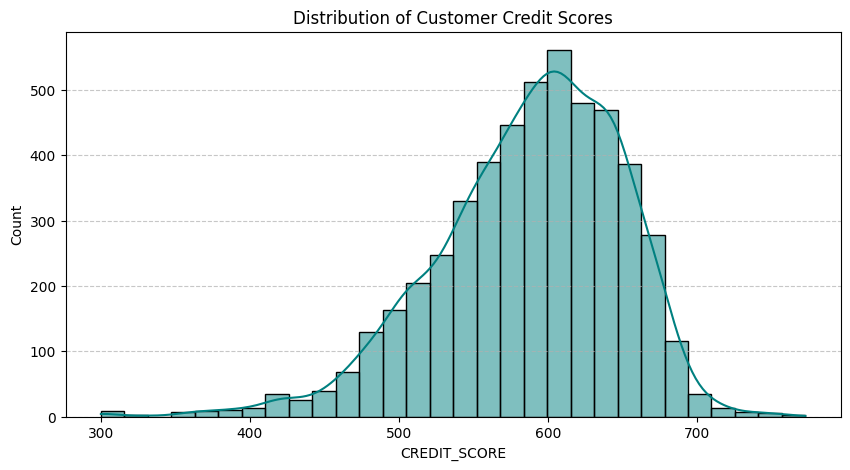

In [6]:
# 4.1 Credit Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['CREDIT_SCORE'], bins=30, kde=True, color='teal')
plt.title("Distribution of Customer Credit Scores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

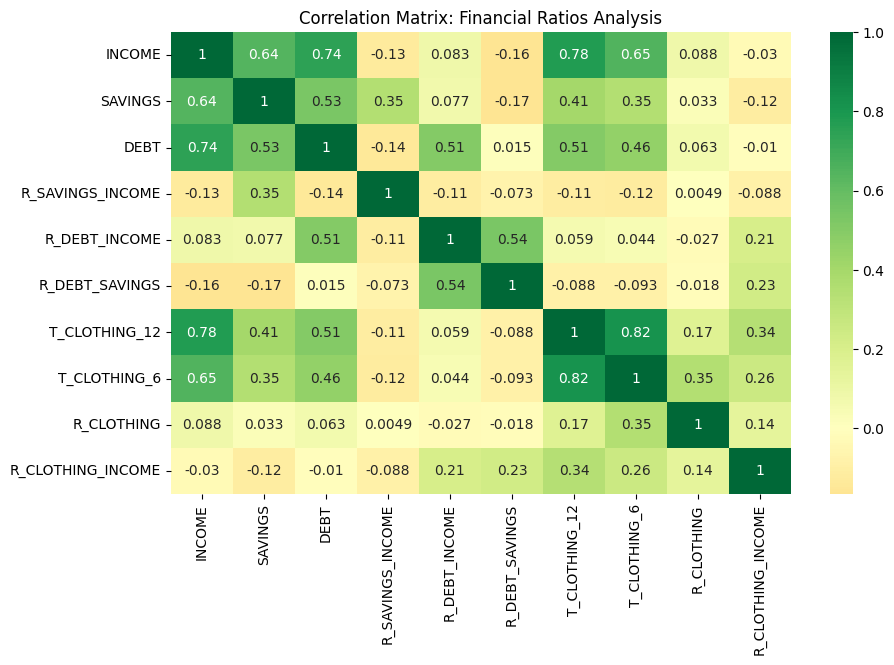

In [8]:
# 4.2 Correlation Heatmap (Financial Ratios)
# Selecting the first 10 numerical features for clarity
plt.figure(figsize=(10, 6))
correlation_matrix = df.iloc[:, 1:11].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation Matrix: Financial Ratios Analysis")
plt.show()

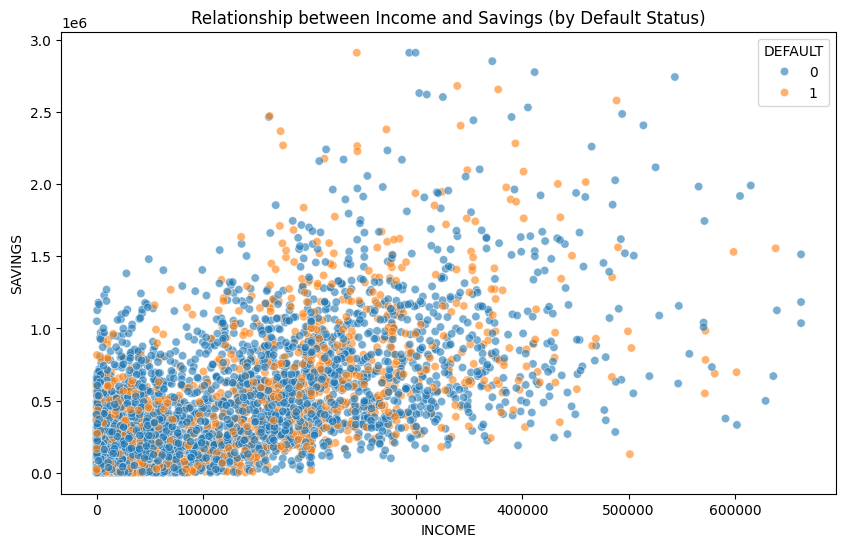

In [9]:
# 4.3 Outlier Detection: Income vs Savings
plt.figure(figsize=(10, 6))
sns.scatterplot(x='INCOME', y='SAVINGS', hue='DEFAULT', data=df, alpha=0.6)
plt.title("Relationship between Income and Savings (by Default Status)")
plt.show()

In [10]:
# Section 5: Data Quality Audit
print("--- Quality Verification Results ---")

# 5.1 Checking for Missing Values
missing_data = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_data}")

# 5.2 Checking for Duplicates
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

# 5.3 Logical Data Integrity Check
# Example: Savings cannot be larger than Income * Ratio in a consistent dataset
# Or checking for negative values in columns that should be positive
negative_income = df[df['INCOME'] < 0].shape[0]
print(f"Records with Negative Income: {negative_income}")

--- Quality Verification Results ---
Total Missing Values: 0
Total Duplicate Rows: 0
Records with Negative Income: 0


## Section 6: Findings and Hypothesis

### 6.1 Data Insights:
* **Key Observations**: The dataset is highly dimensional with 87 features. Credit scores follow a [Normal/Skewed] distribution.
* **Correlation**: Strong correlations are observed between specific expenditure ratios and the target `DEFAULT` status.

### 6.2 Initial Hypotheses:
* **Hypothesis 1**: Customers with higher Debt-to-Income ratios (`R_DEBT_INCOME`) have a higher probability of `DEFAULT`.
* **Hypothesis 2**: `CREDIT_SCORE` is the strongest predictor for creditworthiness in this dataset.

### 6.3 Data Preparation Strategy:
* **Dimensionality Reduction**: Given the high number of columns, feature selection will be necessary.
* **Scaling**: Numerical values like `INCOME` and `SAVINGS` should be standardized due to their wide ranges.